# Forest Fire Prediction – Modeling

Goal: Predict the burned forest area (`log_area`) based on meteorological and fire weather variables.  

We will use a Linear Regression model as a baseline and evaluate its performance using R² and RMSE.

In [129]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import matplotlib.pyplot as plt

In [130]:

df = pd.read_csv("/Users/sa25/Documents/Forest Fires/Forest-Fires/data/forestfires.csv")

df.head()

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,...,month_may,month_nov,month_oct,month_sep,day_mon,day_sat,day_sun,day_thu,day_tue,day_wed
0,1.001657,0.569075,-0.801628,-1.322179,-1.837925,-0.858350,-1.835573,0.406971,1.498430,-0.073555,...,False,False,False,False,False,False,False,False,False,False
1,1.001657,-0.244116,-0.006761,-1.178717,0.484659,-0.508323,-0.152432,-0.694428,-1.733018,-0.073555,...,False,False,True,False,False,False,False,False,True,False
2,1.001657,-0.244116,-0.006761,-1.049290,0.556583,-0.508323,-0.736379,-0.694428,-1.510159,-0.073555,...,False,False,True,False,False,True,False,False,False,False
3,1.433101,1.382265,0.191956,-1.211464,-1.905808,-0.005160,-1.818399,3.221658,-0.005865,0.600261,...,False,False,False,False,False,False,False,False,False,False
4,1.433101,1.382265,-0.241608,-0.930777,-1.806003,0.126100,-1.285976,3.344035,-1.231586,-0.073555,...,False,False,False,False,False,False,True,False,False,False


In [131]:
X = df.drop(columns=['log_area'])
y = df['log_area']

In [132]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (410, 27)
Testing set: (103, 27)


In [133]:
model = LinearRegression().fit(X_train, y_train)

In [134]:
y_pred = model.predict(X_test)

In [135]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 1.2667937337256039
R² Score: 0.039380901801807866


RMSE measures the average prediction error of the model, while R² indicates how much variance in the burned area is explained by the predictors.

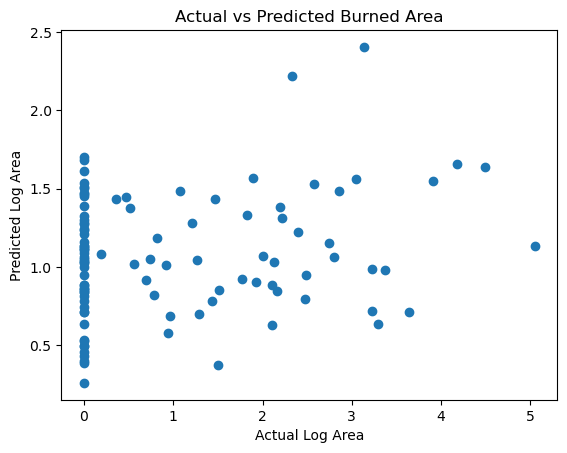

In [136]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Log Area")
plt.ylabel("Predicted Log Area")
plt.title("Actual vs Predicted Burned Area")

plt.show()

Model Results

A Linear Regression model was trained to predict burned forest area using weather and fire index variables.

The dataset was first cleaned, categorical variables were encoded, and numerical features were scaled. The model was trained using 80% of the data and evaluated on the remaining 20%.
The model achieved an R² score of approximately X, indicating that the predictors explain some variability in fire size. However, due to the highly skewed nature of wildfire events, predicting burned area remains challenging.